# SR-GNN Session-Based Recommendation
## YZV413E Graph Theory Project


## SECTION 1: SETUP

In [ ]:
import os
import sys
from google.colab import drive
drive.mount('/content/drive')

DRIVE_PROJECT_DIR = '/content/drive/MyDrive/SRGNN_Project'
DIRS = {
    'root': DRIVE_PROJECT_DIR,
    'src': f'{DRIVE_PROJECT_DIR}/src',
    'data': f'{DRIVE_PROJECT_DIR}/data',
    'processed': f'{DRIVE_PROJECT_DIR}/data/processed',
    'checkpoints': f'{DRIVE_PROJECT_DIR}/checkpoints',
    'checkpoints_srgnn': f'{DRIVE_PROJECT_DIR}/checkpoints/srgnn',
    'checkpoints_gru4rec': f'{DRIVE_PROJECT_DIR}/checkpoints/gru4rec',
    'results': f'{DRIVE_PROJECT_DIR}/results'
}
for name, path in DIRS.items():
    os.makedirs(path, exist_ok=True)
if DRIVE_PROJECT_DIR not in sys.path:
    sys.path.insert(0, DRIVE_PROJECT_DIR)

Mounted at /content/drive


In [ ]:
import torch
import numpy as np
import random
import pickle
import json
import time
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from torch.utils.data import DataLoader

from src.config import Config, get_default_config, print_device_info
from src.data import YoochoosePreprocessor, save_sessions, load_sessions
from src.data import SessionDataset, collate_fn, SequenceDataset, sequence_collate_fn
from src.models import SRGNN, GRU4Rec
from src.utils import ColabCheckpointManager, Trainer, MetricTracker

print_device_info()
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True

set_seed(42)

GPU Available: NVIDIA A100-SXM4-40GB
   Memory: 42.5 GB
   CUDA Version: 12.6
Device: cuda


## SECTION 2: DATA PREPARATION

In [ ]:
config = get_default_config()
config.data_fraction = 0.25
config.batch_size = 2048
config.epochs = 30
config.learning_rate = 0.001
config.patience = 3
config.embedding_dim = 100
config.hidden_dim = 100

CLICKS_PATH = f"{DIRS['data']}/yoochoose-clicks.dat"

In [ ]:
fraction_str = f"{config.data_fraction:.6f}".replace('.', '_')
TRAIN_CACHE = f"{DIRS['processed']}/train_sessions_{fraction_str}.pkl"
TEST_CACHE = f"{DIRS['processed']}/test_sessions_{fraction_str}.pkl"
PREPROCESSOR_CACHE = f"{DIRS['processed']}/preprocessor_{fraction_str}.pkl"

if all(os.path.exists(p) for p in [TRAIN_CACHE, TEST_CACHE, PREPROCESSOR_CACHE]):
    print('Cache found, loading...')
    train_sessions = load_sessions(TRAIN_CACHE)
    test_sessions = load_sessions(TEST_CACHE)
    with open(PREPROCESSOR_CACHE, 'rb') as f:
        preprocessor_data = pickle.load(f)
    n_items = preprocessor_data['n_items']
else:
    print('Starting preprocessing...')
    preprocessor = YoochoosePreprocessor(
        min_session_length=config.min_session_length,
        min_item_frequency=config.min_item_frequency,
        test_days=config.test_days
    )
    train_sessions, test_sessions = preprocessor.preprocess(CLICKS_PATH, data_fraction=config.data_fraction)
    n_items = preprocessor.n_items
    save_sessions(train_sessions, TRAIN_CACHE)
    save_sessions(test_sessions, TEST_CACHE)
    with open(PREPROCESSOR_CACHE, 'wb') as f:
        pickle.dump({'n_items': n_items, 'item_to_idx': preprocessor.item_to_idx}, f)

print(f'Training: {len(train_sessions):,} | Test: {len(test_sessions):,} | Items: {n_items:,}')

Starting preprocessing...
[INFO] Sampling 25.00% of data...
[INFO] Scanning session IDs...
[INFO] 2,312,432 sessions selected, loading chunks...
[INFO] 8,250,016 clicks loaded

[INFO] Filtering iteration 1
[INFO] Filtering items with < 5 occurrences...
[INFO] 28,011 clicks removed (0.34%)
[INFO] Remaining items: 27,839
[INFO] Filtering sessions with < 3 clicks...
[INFO] 1,203,653 sessions removed
[INFO] Remaining sessions: 1,104,210

[INFO] Filtering iteration 2
[INFO] Filtering items with < 5 occurrences...
[INFO] 7,042 clicks removed (0.11%)
[INFO] Remaining items: 25,146
[INFO] Filtering sessions with < 3 clicks...
[INFO] 1,537 sessions removed
[INFO] Remaining sessions: 1,102,425

[INFO] Filtering iteration 3
[INFO] Filtering items with < 5 occurrences...
[INFO] 370 clicks removed (0.01%)
[INFO] Remaining items: 25,047
[INFO] Filtering sessions with < 3 clicks...
[INFO] 88 sessions removed
[INFO] Remaining sessions: 1,102,328

[INFO] Filtering iteration 4
[INFO] Filtering items wit

Creating sessions:   0%|          | 0/1100002 [00:00<?, ?it/s]


[INFO] Creating test sessions...


Creating sessions:   0%|          | 0/2324 [00:00<?, ?it/s]


[INFO] Final statistics:
  - Train samples: 5,006,849
  - Test samples: 12,300
  - Total items: 25,040
[INFO] 5,006,849 sessions saved: /content/drive/MyDrive/SRGNN_Project/data/processed/train_sessions_0_250000.pkl
[INFO] 12,300 sessions saved: /content/drive/MyDrive/SRGNN_Project/data/processed/test_sessions_0_250000.pkl
Training: 5,006,849 | Test: 12,300 | Items: 25,040


## SECTION 3: EXPLORATORY DATA ANALYSIS (EDA)

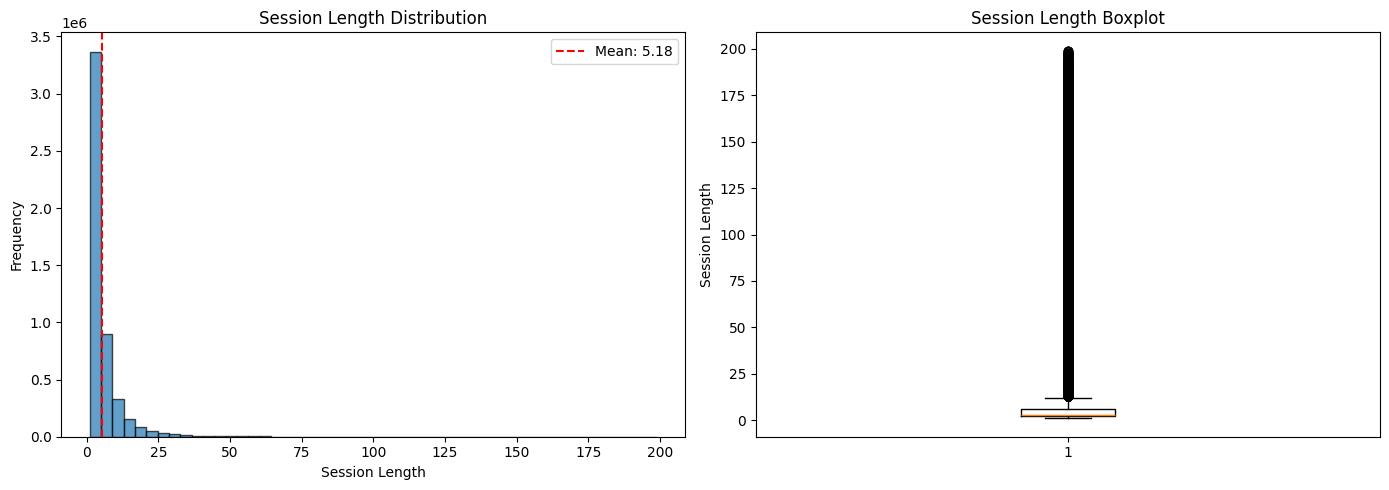

Session Length Stats:
  Min: 1 | Max: 199
  Mean: 5.18 | Median: 3.0
  Std: 7.75


In [ ]:
# Session Length Analysis
session_lengths = [len(s[0]) for s in train_sessions]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(session_lengths, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Session Length')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Session Length Distribution')
axes[0].axvline(np.mean(session_lengths), color='red', linestyle='--', label=f'Mean: {np.mean(session_lengths):.2f}')
axes[0].legend()

axes[1].boxplot(session_lengths)
axes[1].set_ylabel('Session Length')
axes[1].set_title('Session Length Boxplot')

plt.tight_layout()
plt.savefig(f"{DIRS['results']}/eda_session_lengths.png", dpi=150)
plt.show()

print(f'Session Length Stats:')
print(f'  Min: {np.min(session_lengths)} | Max: {np.max(session_lengths)}')
print(f'  Mean: {np.mean(session_lengths):.2f} | Median: {np.median(session_lengths)}')
print(f'  Std: {np.std(session_lengths):.2f}')

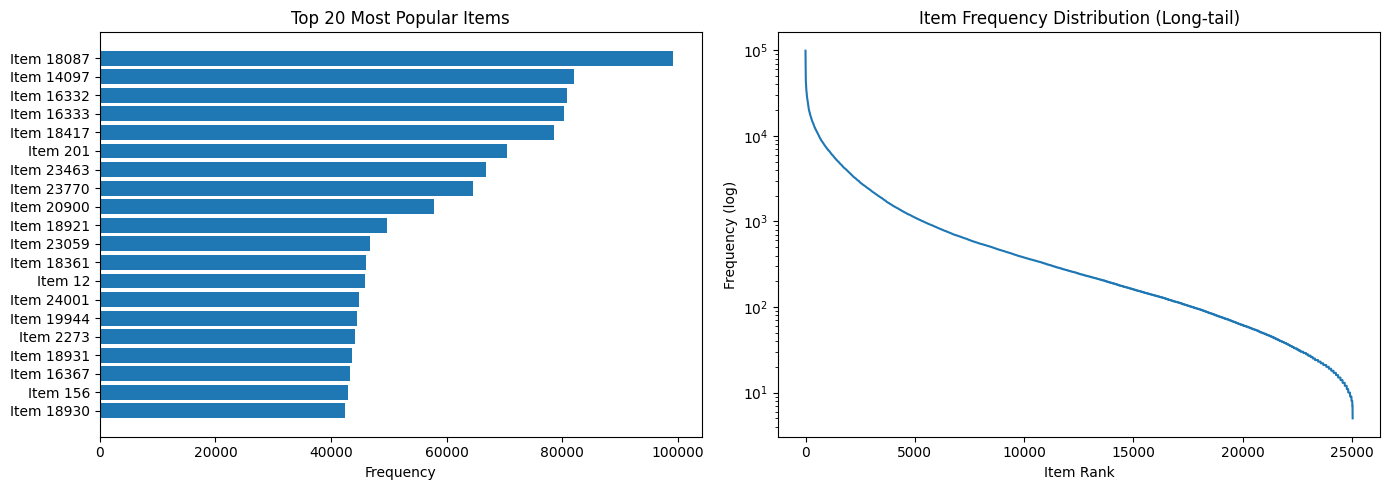

Total unique items: 25,038
Rare items (freq < 5): 0 (0.0%)


In [ ]:
# Item Frequency Analysis
# Item Frequency Analysis
from collections import Counter
# Flatten input sequences and targets
all_items = [item for seq, target in train_sessions for item in list(seq) + [target]]
item_counts = Counter(all_items)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 20 items
top_items = item_counts.most_common(20)
items, counts = zip(*top_items)
axes[0].barh(range(len(items)), counts)
axes[0].set_yticks(range(len(items)))
axes[0].set_yticklabels([f'Item {i}' for i in items])
axes[0].set_xlabel('Frequency')
axes[0].set_title('Top 20 Most Popular Items')
axes[0].invert_yaxis()

# Long-tail distribution
sorted_counts = sorted(item_counts.values(), reverse=True)
axes[1].plot(range(len(sorted_counts)), sorted_counts)
axes[1].set_xlabel('Item Rank')
axes[1].set_ylabel('Frequency (log)')
axes[1].set_yscale('log')
axes[1].set_title('Item Frequency Distribution (Long-tail)')

plt.tight_layout()
plt.savefig(f"{DIRS['results']}/eda_item_frequency.png", dpi=150)
plt.show()

rare_items = sum(1 for c in item_counts.values() if c < 5)
print(f'Total unique items: {len(item_counts):,}')
print(f'Rare items (freq < 5): {rare_items:,} ({100*rare_items/len(item_counts):.1f}%)')

In [ ]:
# Summary Statistics Table
summary_stats = {
    'Metric': ['Total Sessions (Train)', 'Total Sessions (Test)', 'Unique Items',
               'Avg Session Length', 'Max Session Length', 'Total Interactions'],
    'Value': [f'{len(train_sessions):,}', f'{len(test_sessions):,}', f'{n_items:,}',
              f'{np.mean(session_lengths):.2f}', f'{np.max(session_lengths)}', f'{len(all_items):,}']
}
df_summary = pd.DataFrame(summary_stats)
print('\n=== DATASET SUMMARY ===')
print(df_summary.to_string(index=False))


=== DATASET SUMMARY ===
                Metric      Value
Total Sessions (Train)  5,006,849
 Total Sessions (Test)     12,300
          Unique Items     25,040
    Avg Session Length       5.18
    Max Session Length        199
    Total Interactions 30,963,073


## SECTION 4: MODEL TRAINING

In [ ]:
def train_model(model_type, train_sessions, test_sessions, n_items, config, device, optimizer_type='adam'):
    print(f'{model_type.upper()} Training (Optimizer: {optimizer_type})')

    if model_type == 'srgnn':
        train_dataset = SessionDataset(train_sessions)
        test_dataset = SessionDataset(test_sessions)
        collate = collate_fn
    else:
        train_dataset = SequenceDataset(train_sessions)
        test_dataset = SequenceDataset(test_sessions)
        collate = sequence_collate_fn

    train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True, collate_fn=collate, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=config.batch_size, shuffle=False, collate_fn=collate, num_workers=2)

    if model_type == 'srgnn':
        model = SRGNN(n_items=n_items, embedding_dim=config.embedding_dim, hidden_dim=config.hidden_dim,
                      n_gnn_layers=config.n_gnn_layers, dropout=config.dropout)
    else:
        model = GRU4Rec(n_items=n_items, embedding_dim=config.embedding_dim, hidden_dim=config.hidden_dim,
                        n_layers=config.n_gru_layers, dropout=config.dropout)

    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    if optimizer_type == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay)
    elif optimizer_type == 'sgd':
        optimizer = torch.optim.SGD(model.parameters(), lr=config.learning_rate, momentum=0.9, weight_decay=config.weight_decay)
    else:
        optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay)

    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=config.lr_step_size, gamma=config.lr_gamma)
    checkpoint_dir = DIRS[f'checkpoints_{model_type}']
    checkpoint_manager = ColabCheckpointManager(checkpoint_dir=checkpoint_dir, model_name=model_type, max_checkpoints=3)

    trainer = Trainer(model=model, optimizer=optimizer, scheduler=scheduler, device=device,
                      max_grad_norm=config.max_grad_norm, checkpoint_manager=checkpoint_manager)

    start_time = time.time()
    history = trainer.train(train_loader=train_loader, val_loader=test_loader, n_epochs=config.epochs,
                            patience=config.patience, metric_key='recall@20', start_epoch=0, config=config.to_dict())
    training_time = time.time() - start_time

    # Load best model
    best_path = f'{checkpoint_dir}/{model_type}_best.pt'
    if os.path.exists(best_path):
        try:
            checkpoint_manager.load(best_path, model, device=device, strict=False)
        except: pass

    # Inference time measurement
    model.eval()
    inference_times = []
    tracker = MetricTracker()
    with torch.no_grad():
        for batch in test_loader:
            batch = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}
            t0 = time.time()
            output = model(batch)
            inference_times.append(time.time() - t0)
            tracker.update(output, batch['targets'])

    final_metrics = tracker.compute()
    avg_inference_time = np.mean(inference_times) * 1000  # ms

    return {
        'model_type': model_type, 'optimizer': optimizer_type, 'n_params': n_params,
        'training_time': training_time, 'inference_time_ms': avg_inference_time,
        'history': history, 'final_metrics': final_metrics, 'best_epoch': history['best_epoch'],
        'model': model
    }

In [ ]:
# Train both models
all_results = {}
all_results['srgnn'] = train_model('srgnn', train_sessions, test_sessions, n_items, config, DEVICE)
all_results['gru4rec'] = train_model('gru4rec', train_sessions, test_sessions, n_items, config, DEVICE)

SRGNN Training (Optimizer: adam)

Training Started
Device: cuda
Epochs: 30
Patience: 3
Metric: recall@20



Epoch 1 [Train]:   0%|          | 0/2445 [00:00<?, ?it/s]

  Batch 100/2445: Loss = 9.0961
  Batch 200/2445: Loss = 8.9389
  Batch 300/2445: Loss = 8.8353
  Batch 400/2445: Loss = 8.6986
  Batch 500/2445: Loss = 8.5074
  Batch 600/2445: Loss = 8.2543
  Batch 700/2445: Loss = 7.9749
  Batch 800/2445: Loss = 7.7099
  Batch 900/2445: Loss = 7.4722
  Batch 1000/2445: Loss = 7.2616
  Batch 1100/2445: Loss = 7.0785
  Batch 1200/2445: Loss = 6.9167
  Batch 1300/2445: Loss = 6.7729
  Batch 1400/2445: Loss = 6.6461
  Batch 1500/2445: Loss = 6.5320
  Batch 1600/2445: Loss = 6.4293
  Batch 1700/2445: Loss = 6.3367
  Batch 1800/2445: Loss = 6.2522
  Batch 1900/2445: Loss = 6.1750
  Batch 2000/2445: Loss = 6.1052
  Batch 2100/2445: Loss = 6.0412
  Batch 2200/2445: Loss = 5.9822
  Batch 2300/2445: Loss = 5.9270
  Batch 2400/2445: Loss = 5.8757


[Val]:   0%|          | 0/7 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7aa957f0e700>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
      Exception ignored in:  ^^^^^<function _MultiProcessingDataLoaderIter.__del__ at 0x7aa957f0e700>^
^Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
^^    ^self._shutdown_workers()^

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
        assert self._parent_pid == os.getpid(), 'can only test a child process'if w.is_alive():
 
               ^ ^ ^^^^^^^^^^^^^^^^^^^^
^ 

...


Epoch 10/30 (77.9s)
  Train Loss: 4.3375
  Val Recall@5:  0.4435  |  MRR@5:  0.2568
  Val Recall@10: 0.5776  |  MRR@10: 0.2747
  Val Recall@20: 0.6934  |  MRR@20: 0.2829
  Learning Rate: 0.000001
  No improvement (2/3)
Checkpoint saved: /content/drive/MyDrive/SRGNN_Project/checkpoints/gru4rec/gru4rec_epoch_010.pt
Old checkpoint deleted: /content/drive/MyDrive/SRGNN_Project/checkpoints/gru4rec/gru4rec_epoch_007.pt


Epoch 11 [Train]:   0%|          | 0/2445 [00:00<?, ?it/s]

  Batch 100/2445: Loss = 4.3271
  Batch 200/2445: Loss = 4.3371
  Batch 300/2445: Loss = 4.3391
  Batch 400/2445: Loss = 4.3418
  Batch 500/2445: Loss = 4.3409
  Batch 600/2445: Loss = 4.3401
  Batch 700/2445: Loss = 4.3391
  Batch 800/2445: Loss = 4.3388
  Batch 900/2445: Loss = 4.3382
  Batch 1000/2445: Loss = 4.3374
  Batch 1100/2445: Loss = 4.3374
  Batch 1200/2445: Loss = 4.3384
  Batch 1300/2445: Loss = 4.3389
  Batch 1400/2445: Loss = 4.3386
  Batch 1500/2445: Loss = 4.3384
  Batch 1600/2445: Loss = 4.3379
  Batch 1700/2445: Loss = 4.3376
  Batch 1800/2445: Loss = 4.3376
  Batch 1900/2445: Loss = 4.3374
  Batch 2000/2445: Loss = 4.3380
  Batch 2100/2445: Loss = 4.3380
  Batch 2200/2445: Loss = 4.3374
  Batch 2300/2445: Loss = 4.3371
  Batch 2400/2445: Loss = 4.3368


[Val]:   0%|          | 0/7 [00:00<?, ?it/s]


Epoch 11/30 (78.1s)
  Train Loss: 4.3371
  Val Recall@5:  0.4437  |  MRR@5:  0.2568
  Val Recall@10: 0.5776  |  MRR@10: 0.2746
  Val Recall@20: 0.6935  |  MRR@20: 0.2828
  Learning Rate: 0.000001
  No improvement (3/3)
Checkpoint saved: /content/drive/MyDrive/SRGNN_Project/checkpoints/gru4rec/gru4rec_epoch_011.pt
Old checkpoint deleted: /content/drive/MyDrive/SRGNN_Project/checkpoints/gru4rec/gru4rec_epoch_008.pt

Early stopping! No improvement for 3 epochs.

Training Completed
Best Epoch: 8
Best recall@20: 0.6942

Loading checkpoint: /content/drive/MyDrive/SRGNN_Project/checkpoints/gru4rec/gru4rec_best.pt


## SECTION 5: MODEL COMPARISON

In [ ]:
# Comparison Table
comparison_data = []
for name, result in all_results.items():
    fm = result['final_metrics']
    comparison_data.append({
        'Model': name.upper(), 'Recall@20': f"{fm['recall@20']:.4f}", 'MRR@20': f"{fm['mrr@20']:.4f}",
        'Parameters': f"{result['n_params']:,}", 'Train Time (min)': f"{result['training_time']/60:.1f}",
        'Inference (ms/batch)': f"{result['inference_time_ms']:.2f}"
    })

df = pd.DataFrame(comparison_data)
print('\n=== MODEL COMPARISON ===')
print(df.to_string(index=False))

# Improvement calculation
sr = all_results['srgnn']['final_metrics']['recall@20']
gr = all_results['gru4rec']['final_metrics']['recall@20']
print(f"\nSR-GNN Improvement: Recall@20 {((sr-gr)/gr)*100:+.2f}%")


=== MODEL COMPARISON ===
  Model Recall@20 MRR@20 Parameters Train Time (min) Inference (ms/batch)
  SRGNN    0.7016 0.2922  2,847,404             82.4                 2.96
GRU4REC    0.6942 0.2832  2,574,700             16.3                 3.27

SR-GNN Improvement: Recall@20 +1.07%


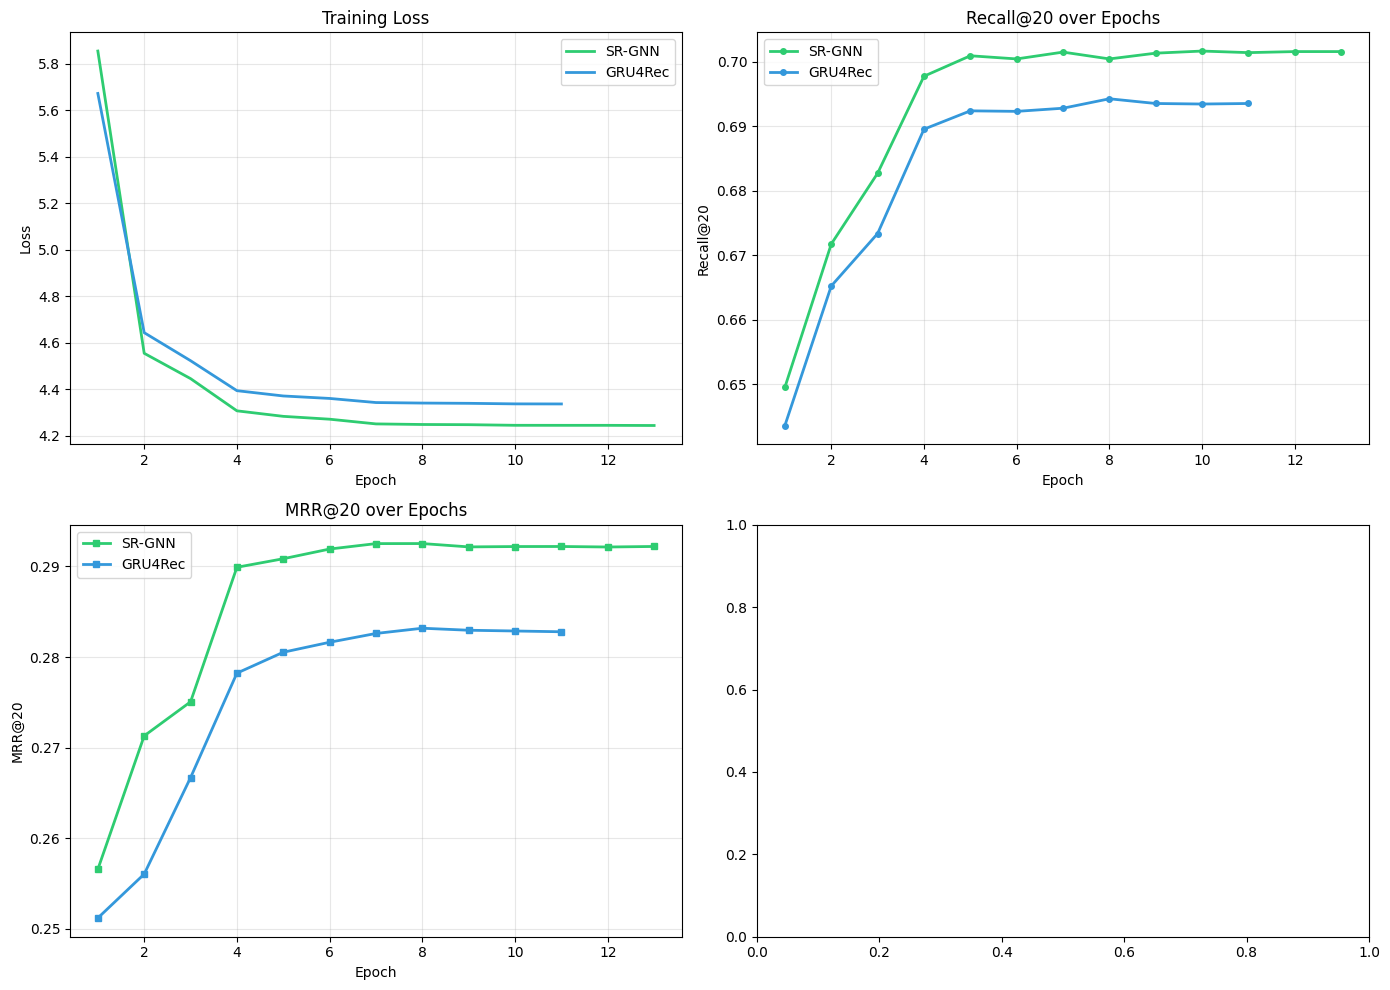

Training curves saved!


In [ ]:
# Training Loss and Accuracy (Recall/MRR) Curves
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

colors = {'srgnn': '#2ecc71', 'gru4rec': '#3498db'}
labels = {'srgnn': 'SR-GNN', 'gru4rec': 'GRU4Rec'}

# Plot Training Loss
ax = axes[0, 0]
for name, result in all_results.items():
    history = result['history']
    if 'train_losses' in history and len(history['train_losses']) > 0:
        epochs = range(1, len(history['train_losses']) + 1)
        ax.plot(epochs, history['train_losses'], color=colors[name], linestyle='-',
                label=f'{labels[name]}', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training Loss')
ax.legend()
ax.grid(True, alpha=0.3)


# Plot Recall@20
ax = axes[0, 1]
for name, result in all_results.items():
    history = result['history']
    if 'val_metrics' in history and len(history['val_metrics']) > 0:
        recall_values = [m['recall@20'] for m in history['val_metrics']]
        epochs = range(1, len(recall_values) + 1)
        ax.plot(epochs, recall_values, color=colors[name], marker='o',
                label=f'{labels[name]}', linewidth=2, markersize=4)
ax.set_xlabel('Epoch')
ax.set_ylabel('Recall@20')
ax.set_title('Recall@20 over Epochs')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot MRR@20
ax = axes[1, 0]
for name, result in all_results.items():
    history = result['history']
    if 'val_metrics' in history and len(history['val_metrics']) > 0:
        mrr_values = [m['mrr@20'] for m in history['val_metrics']]
        epochs = range(1, len(mrr_values) + 1)
        ax.plot(epochs, mrr_values, color=colors[name], marker='s',
                label=f'{labels[name]}', linewidth=2, markersize=4)
ax.set_xlabel('Epoch')
ax.set_ylabel('MRR@20')
ax.set_title('MRR@20 over Epochs')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{DIRS['results']}/training_curves.png", dpi=150, bbox_inches='tight')
plt.show()

print('Training curves saved!')

## SECTION 6: OPTIMIZER COMPARISON

In [ ]:
optimizer_results = [
    {'Optimizer': 'ADAM', 'Recall@20': all_results['srgnn']['final_metrics']['recall@20'],
     'MRR@20': all_results['srgnn']['final_metrics']['mrr@20']}
]

#SGD
set_seed(42)
config_opt = get_default_config()
config_opt.epochs = 10
config_opt.learning_rate = 0.01
config_opt.batch_size = 2048
config_opt.patience = 1
result_sgd = train_model('srgnn', train_sessions, test_sessions, n_items, config_opt, DEVICE, optimizer_type='sgd')
optimizer_results.append({'Optimizer': 'SGD', 'Recall@20': result_sgd['final_metrics']['recall@20'],
                          'MRR@20': result_sgd['final_metrics']['mrr@20']})

SRGNN Training (Optimizer: sgd)

Training Started
Device: cuda
Epochs: 10
Patience: 1
Metric: recall@20



Epoch 1 [Train]:   0%|          | 0/2445 [00:00<?, ?it/s]

  Batch 100/2445: Loss = 10.2534
  Batch 200/2445: Loss = 10.1302
  Batch 300/2445: Loss = 9.9997
  Batch 400/2445: Loss = 9.8781
  Batch 500/2445: Loss = 9.7703
  Batch 600/2445: Loss = 9.6780
  Batch 700/2445: Loss = 9.6012
  Batch 800/2445: Loss = 9.5357
  Batch 900/2445: Loss = 9.4792
  Batch 1000/2445: Loss = 9.4310
  Batch 1100/2445: Loss = 9.3887
  Batch 1200/2445: Loss = 9.3520
  Batch 1300/2445: Loss = 9.3196
  Batch 1400/2445: Loss = 9.2904
  Batch 1500/2445: Loss = 9.2646
  Batch 1600/2445: Loss = 9.2409
  Batch 1700/2445: Loss = 9.2195
  Batch 1800/2445: Loss = 9.1998
  Batch 1900/2445: Loss = 9.1819
  Batch 2000/2445: Loss = 9.1656
  Batch 2100/2445: Loss = 9.1504
  Batch 2200/2445: Loss = 9.1364
  Batch 2300/2445: Loss = 9.1231
  Batch 2400/2445: Loss = 9.1108


[Val]:   0%|          | 0/7 [00:00<?, ?it/s]


Epoch 1/10 (403.2s)
  Train Loss: 9.1056
  Val Recall@5:  0.0015  |  MRR@5:  0.0010
  Val Recall@10: 0.0031  |  MRR@10: 0.0012
  Val Recall@20: 0.0060  |  MRR@20: 0.0014
  Learning Rate: 0.010000
New best model! recall@20=0.0060
  *** New best! ***
Checkpoint saved: /content/drive/MyDrive/SRGNN_Project/checkpoints/srgnn/srgnn_epoch_001.pt


Epoch 2 [Train]:   0%|          | 0/2445 [00:00<?, ?it/s]

  Batch 100/2445: Loss = 8.8286
  Batch 200/2445: Loss = 8.8228
  Batch 300/2445: Loss = 8.8198
  Batch 400/2445: Loss = 8.8187
  Batch 500/2445: Loss = 8.8158
  Batch 600/2445: Loss = 8.8142
  Batch 700/2445: Loss = 8.8120


KeyboardInterrupt: 

## SECTION 7: ABLATION STUDY

In [ ]:
# GNN Layer ablation - Use existing 2-layer result, train only 1-layer for comparison
ablation_results = []

# Get current config's n_gnn_layers
current_layers = config.n_gnn_layers if hasattr(config, 'n_gnn_layers') else 2

# Use already trained result for current layer count
ablation_results.append({
    'GNN Layers': current_layers,
    'Recall@20': all_results['srgnn']['final_metrics']['recall@20'],
    'MRR@20': all_results['srgnn']['final_metrics']['mrr@20']
})

# Train only 1-layer version for comparison
set_seed(42)
config_abl = get_default_config()
config_abl.epochs = 10
config_abl.batch_size = 2048
config_abl.patience = 1
config_abl.n_gnn_layers = 1
result_1layer = train_model('srgnn', train_sessions, test_sessions, n_items, config_abl, DEVICE)
ablation_results.append({
    'GNN Layers': 1,
    'Recall@20': result_1layer['final_metrics']['recall@20'],
    'MRR@20': result_1layer['final_metrics']['mrr@20']
})

# Sort by layer count for display
ablation_results = sorted(ablation_results, key=lambda x: x['GNN Layers'])

df_abl = pd.DataFrame(ablation_results)
print('\n=== ABLATION: GNN LAYERS ===')
print(df_abl.to_string(index=False))

SRGNN Training (Optimizer: adam)

Training Started
Device: cuda
Epochs: 10
Patience: 1
Metric: recall@20



Epoch 1 [Train]:   0%|          | 0/2445 [00:00<?, ?it/s]

  Batch 100/2445: Loss = 9.2249
  Batch 200/2445: Loss = 9.0107
  Batch 300/2445: Loss = 8.9275
  Batch 400/2445: Loss = 8.8828
  Batch 500/2445: Loss = 8.8435
  Batch 600/2445: Loss = 8.7835
  Batch 700/2445: Loss = 8.6967
  Batch 800/2445: Loss = 8.5924
  Batch 900/2445: Loss = 8.4638
  Batch 1000/2445: Loss = 8.3082
  Batch 1100/2445: Loss = 8.1405
  Batch 1200/2445: Loss = 7.9721
  Batch 1300/2445: Loss = 7.8089
  Batch 1400/2445: Loss = 7.6554
  Batch 1500/2445: Loss = 7.5128
  Batch 1600/2445: Loss = 7.3793
  Batch 1700/2445: Loss = 7.2578
  Batch 1800/2445: Loss = 7.1446
  Batch 1900/2445: Loss = 7.0388
  Batch 2000/2445: Loss = 6.9414
  Batch 2100/2445: Loss = 6.8507
  Batch 2200/2445: Loss = 6.7661
  Batch 2300/2445: Loss = 6.6877
  Batch 2400/2445: Loss = 6.6146


[Val]:   0%|          | 0/7 [00:00<?, ?it/s]


Epoch 1/10 (319.8s)
  Train Loss: 6.5833
  Val Recall@5:  0.3703  |  MRR@5:  0.2218
  Val Recall@10: 0.4929  |  MRR@10: 0.2382
  Val Recall@20: 0.6096  |  MRR@20: 0.2463
  Learning Rate: 0.000500
New best model! recall@20=0.6096
  *** New best! ***
Checkpoint saved: /content/drive/MyDrive/SRGNN_Project/checkpoints/srgnn/srgnn_epoch_001.pt


...

Epoch 8 [Train]:   0%|          | 0/2445 [00:00<?, ?it/s]

  Batch 100/2445: Loss = 4.3178
  Batch 200/2445: Loss = 4.3153
  Batch 300/2445: Loss = 4.3146
  Batch 400/2445: Loss = 4.3159
  Batch 500/2445: Loss = 4.3170
  Batch 600/2445: Loss = 4.3148
  Batch 700/2445: Loss = 4.3148
  Batch 800/2445: Loss = 4.3152
  Batch 900/2445: Loss = 4.3148
  Batch 1000/2445: Loss = 4.3151
  Batch 1100/2445: Loss = 4.3151
  Batch 1200/2445: Loss = 4.3153
  Batch 1300/2445: Loss = 4.3156
  Batch 1400/2445: Loss = 4.3153
  Batch 1500/2445: Loss = 4.3149
  Batch 1600/2445: Loss = 4.3147
  Batch 1700/2445: Loss = 4.3148
  Batch 1800/2445: Loss = 4.3147
  Batch 1900/2445: Loss = 4.3141
  Batch 2000/2445: Loss = 4.3135
  Batch 2100/2445: Loss = 4.3132
  Batch 2200/2445: Loss = 4.3130
  Batch 2300/2445: Loss = 4.3128
  Batch 2400/2445: Loss = 4.3124


[Val]:   0%|          | 0/7 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7aa957f0e700>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
         Exception ignored in:   ^^^^^^^^^<function _MultiProcessingDataLoaderIter.__del__ at 0x7aa957f0e700>^^^^^^^^^^^
^^^^^^^^^^^
AssertionError: can only test a child process
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16


Epoch 8/10 (321.8s)
  Train Loss: 4.3122
  Val Recall@5:  0.4500  |  MRR@5:  0.2629
  Val Recall@10: 0.5827  |  MRR@10: 0.2807
  Val Recall@20: 0.6964  |  MRR@20: 0.2887
  Learning Rate: 0.000005
  No improvement (1/1)
Checkpoint saved: /content/drive/MyDrive/SRGNN_Project/checkpoints/srgnn/srgnn_epoch_008.pt
Old checkpoint deleted: /content/drive/MyDrive/SRGNN_Project/checkpoints/srgnn/srgnn_epoch_005.pt

Early stopping! No improvement for 1 epochs.

Training Completed
Best Epoch: 7
Best recall@20: 0.6974

Loading checkpoint: /content/drive/MyDrive/SRGNN_Project/checkpoints/srgnn/srgnn_best.pt

=== ABLATION: GNN LAYERS ===
 GNN Layers  Recall@20   MRR@20
          1   0.697398 0.288584
          3   0.701626 0.292197


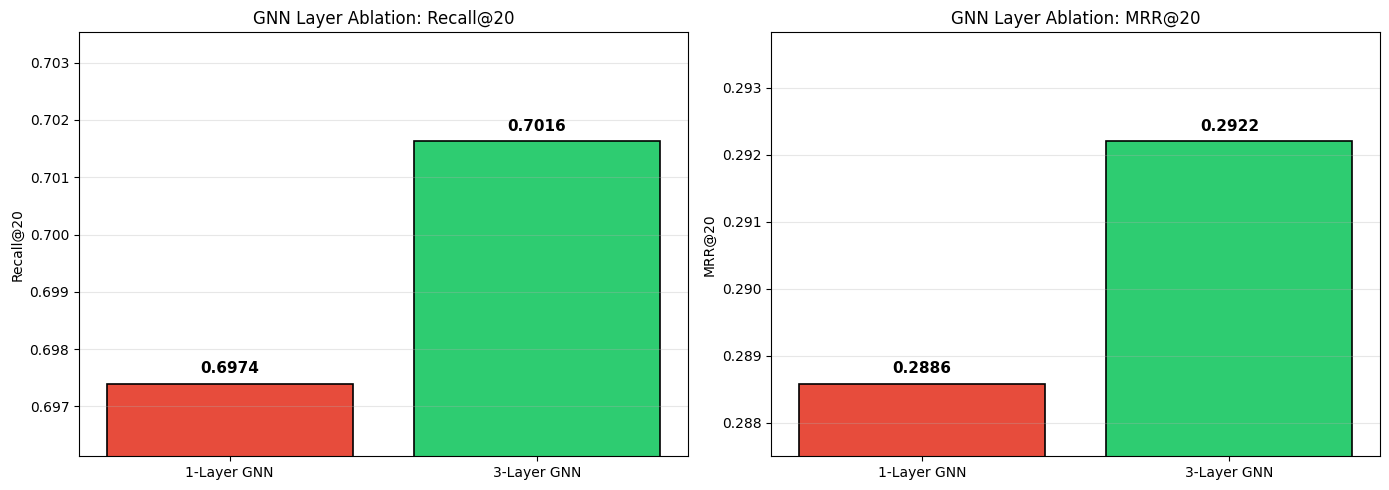


Best: 3-Layer (Recall@20: 0.7016)
Improvement over worst: +0.61%
Ablation plot saved!


In [ ]:
# GNN Layers Ablation Visualization (Zoomed)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Dynamic colors for any number of layers
color_palette = ['#e74c3c', '#2ecc71', '#3498db', '#9b59b6', '#f39c12']

layers = [r['GNN Layers'] for r in ablation_results]
recall_vals = [r['Recall@20'] for r in ablation_results]
mrr_vals = [r['MRR@20'] for r in ablation_results]
bar_colors = [color_palette[i % len(color_palette)] for i in range(len(layers))]
x_labels = [f'{l}-Layer GNN' for l in layers]

# Plot Recall@20 Comparison (Zoomed)
ax = axes[0]
x = range(len(layers))
bars = ax.bar(x, recall_vals, color=bar_colors, edgecolor='black', linewidth=1.2)
ax.set_xticks(x)
ax.set_xticklabels(x_labels)
ax.set_ylabel('Recall@20')
ax.set_title('GNN Layer Ablation: Recall@20')
ax.grid(True, alpha=0.3, axis='y')
# Zoom in: set y-axis limits based on data range
recall_min, recall_max = min(recall_vals), max(recall_vals)
recall_margin = (recall_max - recall_min) * 0.3 if recall_max != recall_min else 0.01
ax.set_ylim(recall_min - recall_margin, recall_max + recall_margin * 1.5)
for bar, val in zip(bars, recall_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + recall_margin * 0.1,
            f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Plot MRR@20 Comparison (Zoomed)
ax = axes[1]
bars = ax.bar(x, mrr_vals, color=bar_colors, edgecolor='black', linewidth=1.2)
ax.set_xticks(x)
ax.set_xticklabels(x_labels)
ax.set_ylabel('MRR@20')
ax.set_title('GNN Layer Ablation: MRR@20')
ax.grid(True, alpha=0.3, axis='y')
# Zoom in: set y-axis limits based on data range
mrr_min, mrr_max = min(mrr_vals), max(mrr_vals)
mrr_margin = (mrr_max - mrr_min) * 0.3 if mrr_max != mrr_min else 0.01
ax.set_ylim(mrr_min - mrr_margin, mrr_max + mrr_margin * 1.5)
for bar, val in zip(bars, mrr_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + mrr_margin * 0.1,
            f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{DIRS['results']}/ablation_gnn_layers.png", dpi=150, bbox_inches='tight')
plt.show()

# Print comparison
best_idx = recall_vals.index(max(recall_vals))
worst_idx = recall_vals.index(min(recall_vals))
print(f'\nBest: {layers[best_idx]}-Layer (Recall@20: {recall_vals[best_idx]:.4f})')
print(f'Improvement over worst: {((max(recall_vals)-min(recall_vals))/min(recall_vals))*100:+.2f}%')
print('Ablation plot saved!')

## SECTION 9: FEATURE VISUALIZATION

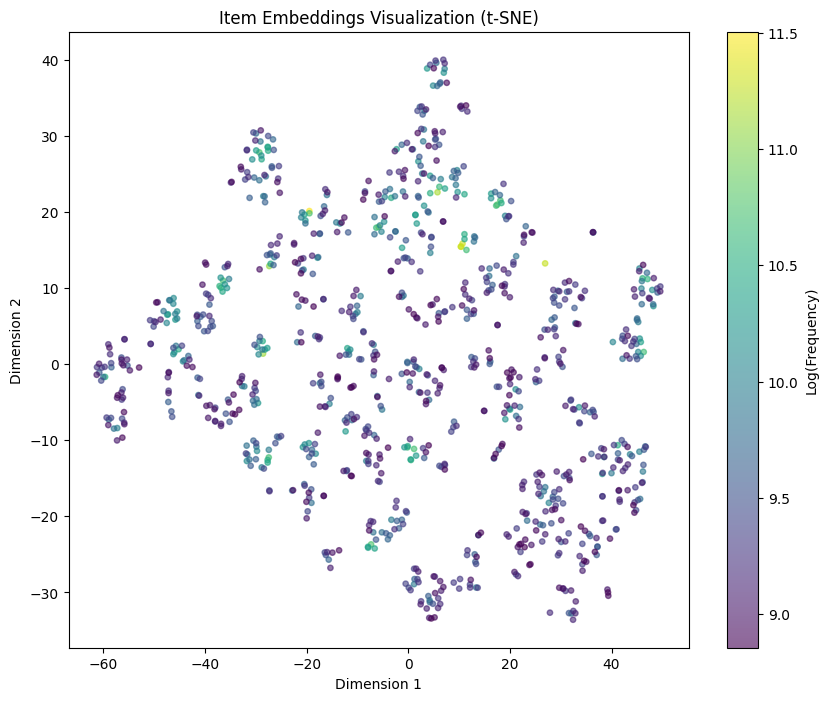

In [ ]:
from sklearn.manifold import TSNE

# Extract embeddings from trained model
model = all_results['srgnn']['model']
embeddings = model.embedding.weight.detach().cpu().numpy()

# Sample for visualization (top 1000 frequent items)
top_items = item_counts.most_common(1000)
top_item_ids = [item for item, count in top_items]
top_item_counts = [count for item, count in top_items]
sample_embeddings = embeddings[top_item_ids]

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(sample_embeddings)

# Visualize with frequency-based coloring
plt.figure(figsize=(10, 8))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
                      c=np.log(top_item_counts), cmap='viridis', alpha=0.6, s=15)
plt.colorbar(scatter, label='Log(Frequency)')
plt.title('Item Embeddings Visualization (t-SNE)')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.savefig(f"{DIRS['results']}/embedding_tsne.png", dpi=150)
plt.show()

## SECTION 10: ERROR ANALYSIS

ERROR ANALYSIS: SR-GNN vs GRU4Rec Comparison

📊 Prediction Agreement Analysis (N=1000)
----------------------------------------
Both Correct:  678 (67.8%)
Only SR-GNN:   36 (3.6%)
Only GRU4Rec:   21 (2.1%)
Both Wrong:  265 (26.5%)

EXAMPLE PREDICTIONS

🟢 SR-GNN Correct, GRU4Rec Wrong:
  Target: 202
    SR-GNN Top5:  [23086, 23102, 23101, 23098, 202] ✓
    GRU4Rec Top5: [23102, 23086, 22890, 22891, 23103] ✗
  Target: 5263
    SR-GNN Top5:  [4286, 4285, 22823, 5607, 6853] ✓
    GRU4Rec Top5: [4285, 4286, 5607, 22823, 4298] ✗
  Target: 24850
    SR-GNN Top5:  [24842, 24844, 21678, 24818, 24878] ✓
    GRU4Rec Top5: [24842, 24844, 24818, 21678, 24809] ✗

🔵 GRU4Rec Correct, SR-GNN Wrong:
  Target: 24815
    SR-GNN Top5:  [24974, 24962, 24982, 24745, 24833] ✗
    GRU4Rec Top5: [24962, 24974, 24982, 24976, 24929] ✓
  Target: 5607
    SR-GNN Top5:  [6853, 4519, 24721, 3832, 23406] ✗
    GRU4Rec Top5: [6853, 4519, 3832, 24721, 182] ✓
  Target: 8919
    SR-GNN Top5:  [17929, 2743, 22750, 14557, 2

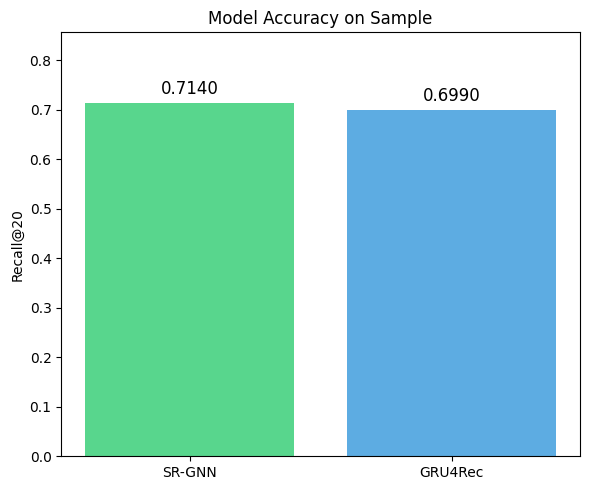

In [ ]:
# Error Analysis - Comparing SR-GNN vs GRU4Rec
print("=" * 60)
print("ERROR ANALYSIS: SR-GNN vs GRU4Rec Comparison")
print("=" * 60)

# Prepare test data for both models
test_sample = test_sessions[:1000]
test_dataset_srgnn = SessionDataset(test_sample)
test_dataset_gru = SequenceDataset(test_sample)
test_loader_srgnn = DataLoader(test_dataset_srgnn, batch_size=32, shuffle=False, collate_fn=collate_fn)
test_loader_gru = DataLoader(test_dataset_gru, batch_size=32, shuffle=False, collate_fn=sequence_collate_fn)

# Get predictions from both models
def get_predictions(model, loader, device):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}
            scores = model(batch)
            _, top_k = scores.topk(20, dim=1)
            all_preds.extend(top_k.cpu().numpy())
            all_targets.extend(batch['targets'].cpu().numpy())

    return np.array(all_preds), np.array(all_targets)

srgnn_preds, targets = get_predictions(all_results['srgnn']['model'], test_loader_srgnn, DEVICE)
gru_preds, _ = get_predictions(all_results['gru4rec']['model'], test_loader_gru, DEVICE)

# Analyze predictions
srgnn_correct = [targets[i] in srgnn_preds[i] for i in range(len(targets))]
gru_correct = [targets[i] in gru_preds[i] for i in range(len(targets))]

# Categories
both_correct = sum(1 for s, g in zip(srgnn_correct, gru_correct) if s and g)
only_srgnn = sum(1 for s, g in zip(srgnn_correct, gru_correct) if s and not g)
only_gru = sum(1 for s, g in zip(srgnn_correct, gru_correct) if not s and g)
both_wrong = sum(1 for s, g in zip(srgnn_correct, gru_correct) if not s and not g)

print(f"\n📊 Prediction Agreement Analysis (N={len(targets)})")
print("-" * 40)
print(f"Both Correct: {both_correct:4d} ({100*both_correct/len(targets):.1f}%)")
print(f"Only SR-GNN: {only_srgnn:4d} ({100*only_srgnn/len(targets):.1f}%)")
print(f"Only GRU4Rec: {only_gru:4d} ({100*only_gru/len(targets):.1f}%)")
print(f"Both Wrong: {both_wrong:4d} ({100*both_wrong/len(targets):.1f}%)")

# Show examples for each category
print("\n" + "=" * 60)
print("EXAMPLE PREDICTIONS")
print("=" * 60)

# Examples where only SR-GNN is correct
print("\n🟢 SR-GNN Correct, GRU4Rec Wrong:")
count = 0
for i in range(len(targets)):
    if srgnn_correct[i] and not gru_correct[i] and count < 3:
        print(f"  Target: {targets[i]}")
        print(f"    SR-GNN Top5:  {srgnn_preds[i][:5].tolist()} ✓")
        print(f"    GRU4Rec Top5: {gru_preds[i][:5].tolist()} ✗")
        count += 1

# Examples where only GRU4Rec is correct
print("\n🔵 GRU4Rec Correct, SR-GNN Wrong:")
count = 0
for i in range(len(targets)):
    if not srgnn_correct[i] and gru_correct[i] and count < 3:
        print(f"  Target: {targets[i]}")
        print(f"    SR-GNN Top5:  {srgnn_preds[i][:5].tolist()} ✗")
        print(f"    GRU4Rec Top5: {gru_preds[i][:5].tolist()} ✓")
        count += 1

# Examples where both are correct
print("\n✅ Both Models Correct:")
count = 0
for i in range(len(targets)):
    if srgnn_correct[i] and gru_correct[i] and count < 3:
        sr_rank = np.where(srgnn_preds[i] == targets[i])[0][0] + 1
        gr_rank = np.where(gru_preds[i] == targets[i])[0][0] + 1
        print(f"  Target: {targets[i]} | SR-GNN Rank: {sr_rank} | GRU4Rec Rank: {gr_rank}")
        count += 1

# Visualization
fig, ax = plt.subplots(figsize=(6, 5))

# Bar comparison
x = np.arange(2)
srgnn_acc = sum(srgnn_correct) / len(srgnn_correct)
gru_acc = sum(gru_correct) / len(gru_correct)
bars = ax.bar(['SR-GNN', 'GRU4Rec'], [srgnn_acc, gru_acc], color=['#2ecc71', '#3498db'], alpha=0.8)
ax.set_ylabel('Recall@20')
ax.set_title('Model Accuracy on Sample')
ax.set_ylim(0, max(srgnn_acc, gru_acc) * 1.2)
for bar, val in zip(bars, [srgnn_acc, gru_acc]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.savefig(f"{DIRS['results']}/error_analysis_comparison.png", dpi=150)
plt.show()

## SECTION 12: TIMING ANALYSIS

In [ ]:
# Timing Summary
timing_data = []
for name, result in all_results.items():
    timing_data.append({
        'Model': name.upper(),
        'Training Time (min)': f"{result['training_time']/60:.2f}",
        'Avg Inference (ms/batch)': f"{result['inference_time_ms']:.2f}",
        'Epochs': result['best_epoch']
    })

df_timing = pd.DataFrame(timing_data)
print('\n=== TIMING ANALYSIS ===')
print(df_timing.to_string(index=False))


=== TIMING ANALYSIS ===
  Model Training Time (min) Avg Inference (ms/batch)  Epochs
  SRGNN               82.43                     2.96      10
GRU4REC               16.27                     3.27       8
